In [667]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import scipy.stats as stats
import scipy.optimize as optimize
import scipy.spatial as spatial
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [668]:
df = pd.read_csv('data/runs/run_20260331_190615_05b7b819/whale_dataset_final.csv')

In [669]:
df.shape

(25728, 23)

In [670]:
df.head(5)

,SIGHTINGDATE,LAT,LON,Presence,SOURCE,SOURCE_DETAIL,PACKAGE_ID,Season,SST_Celsius,Frontal_Value,Chlorophyll_mg_m3,Salinity_PSU,Water_Mass_M_WK,SST_env_source,Chlorophyll_env_source,Frontal_env_source,Salinity_env_source,SST_is_observed,Frontal_is_observed,Chlorophyll_is_observed,Salinity_is_observed,Water_Mass_is_observed,Any_env_missing
0,2002-02-06,41.93,-70.52,1,Visual,RWSAS sightings,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0
1,2002-02-07,41.88,-70.28,1,Visual,RWSAS sightings,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0
2,2002-02-07,42.15,-70.33,1,Visual,RWSAS sightings,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0
3,2002-02-07,42.2,-70.2,1,Visual,RWSAS sightings,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0
4,2002-02-07,42.24,-70.2,1,Visual,RWSAS sightings,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0


In [671]:
df.columns

Index(['SIGHTINGDATE', 'LAT', 'LON', 'Presence', 'SOURCE', 'SOURCE_DETAIL',
       'PACKAGE_ID', 'Season', 'SST_Celsius', 'Frontal_Value',
       'Chlorophyll_mg_m3', 'Salinity_PSU', 'Water_Mass_M_WK',
       'SST_env_source', 'Chlorophyll_env_source', 'Frontal_env_source',
       'Salinity_env_source', 'SST_is_observed', 'Frontal_is_observed',
       'Chlorophyll_is_observed', 'Salinity_is_observed',
       'Water_Mass_is_observed', 'Any_env_missing'],
      dtype='str')

In [672]:
df.dtypes

SIGHTINGDATE                   str
LAT                            str
LON                            str
Presence                       str
SOURCE                         str
SOURCE_DETAIL                  str
PACKAGE_ID                     str
Season                         str
SST_Celsius                    str
Frontal_Value                  str
Chlorophyll_mg_m3              str
Salinity_PSU                   str
Water_Mass_M_WK                str
SST_env_source                 str
Chlorophyll_env_source         str
Frontal_env_source             str
Salinity_env_source            str
SST_is_observed            float64
Frontal_is_observed        float64
Chlorophyll_is_observed    float64
Salinity_is_observed       float64
Water_Mass_is_observed     float64
Any_env_missing            float64
dtype: object

In [673]:
df.describe()

,SST_is_observed,Frontal_is_observed,Chlorophyll_is_observed,Salinity_is_observed,Water_Mass_is_observed,Any_env_missing
count,15727.000000,15727.000000,15727.000000,15727.000000,15727.000000,15727.000000
mean,0.987982,0.985821,0.983341,0.259109,0.986838,0.741845
std,0.108967,0.118234,0.127995,0.438159,0.113972,0.437633
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000
50%,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [674]:
df = df[['SIGHTINGDATE', 'LAT', 'LON', 'Presence', 
         # 'SOURCE', 'SOURCE_DETAIL', 'PACKAGE_ID', 
         'Season', 'SST_Celsius', 'Frontal_Value',
       'Chlorophyll_mg_m3', 'Salinity_PSU', 'Water_Mass_M_WK',
       'SST_env_source', 'Chlorophyll_env_source', 'Frontal_env_source', 'Salinity_env_source', 
       'SST_is_observed', 'Frontal_is_observed', 'Chlorophyll_is_observed', 'Salinity_is_observed',
       'Water_Mass_is_observed', 'Any_env_missing']].copy()

In [675]:
df['SIGHTINGDATE'] = pd.to_datetime(df['SIGHTINGDATE'], errors='coerce')
df['SST_Celsius'] = pd.to_numeric(df['SST_Celsius'], errors='coerce')
df['Chlorophyll_mg_m3'] = pd.to_numeric(df['Chlorophyll_mg_m3'], errors='coerce')
df['Salinity_PSU'] = pd.to_numeric(df['Salinity_PSU'], errors='coerce')
df['Water_Mass_M_WK'] = pd.to_numeric(df['Water_Mass_M_WK'], errors='coerce')
df['Frontal_Value'] = pd.to_numeric(df['Frontal_Value'], errors='coerce')
df['Presence'] = pd.to_numeric(df['Presence'], errors='coerce')
df['LAT'] = pd.to_numeric(df['LAT'], errors='coerce')
df['LON'] = pd.to_numeric(df['LON'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25728 entries, 0 to 25727
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   SIGHTINGDATE             25727 non-null  datetime64[us]
 1   LAT                      25727 non-null  float64       
 2   LON                      25727 non-null  float64       
 3   Presence                 25727 non-null  float64       
 4   Season                   25728 non-null  str           
 5   SST_Celsius              25254 non-null  float64       
 6   Frontal_Value            25125 non-null  float64       
 7   Chlorophyll_mg_m3        24887 non-null  float64       
 8   Salinity_PSU             6244 non-null   float64       
 9   Water_Mass_M_WK          25520 non-null  float64       
 10  SST_env_source           25539 non-null  str           
 11  Chlorophyll_env_source   25466 non-null  str           
 12  Frontal_env_source       25505 non-null  st

In [676]:
df.isna().sum()

SIGHTINGDATE                   1
LAT                            1
LON                            1
Presence                       1
Season                         0
SST_Celsius                  474
Frontal_Value                603
Chlorophyll_mg_m3            841
Salinity_PSU               19484
Water_Mass_M_WK              208
SST_env_source               189
Chlorophyll_env_source       262
Frontal_env_source           223
Salinity_env_source        11652
SST_is_observed            10001
Frontal_is_observed        10001
Chlorophyll_is_observed    10001
Salinity_is_observed       10001
Water_Mass_is_observed     10001
Any_env_missing            10001
dtype: int64

In [677]:
df = df.dropna(subset=['SIGHTINGDATE', 'LAT', 'LON', 'Presence', 
        'SST_Celsius', 'Chlorophyll_mg_m3', 'Water_Mass_M_WK']).reset_index(drop=True).copy()

# Check for number of rows with Prescence = 1 vs 0
print(df['Presence'].value_counts())


Presence
0.0    12650
1.0    12224
Name: count, dtype: int64


# Step 3: Feature Understanding
(Univariate analysis)

- Plotting Feature Distributions
    - Histogram
    - KDE
    - Boxplot

After outlier removal: 24699 rows remaining


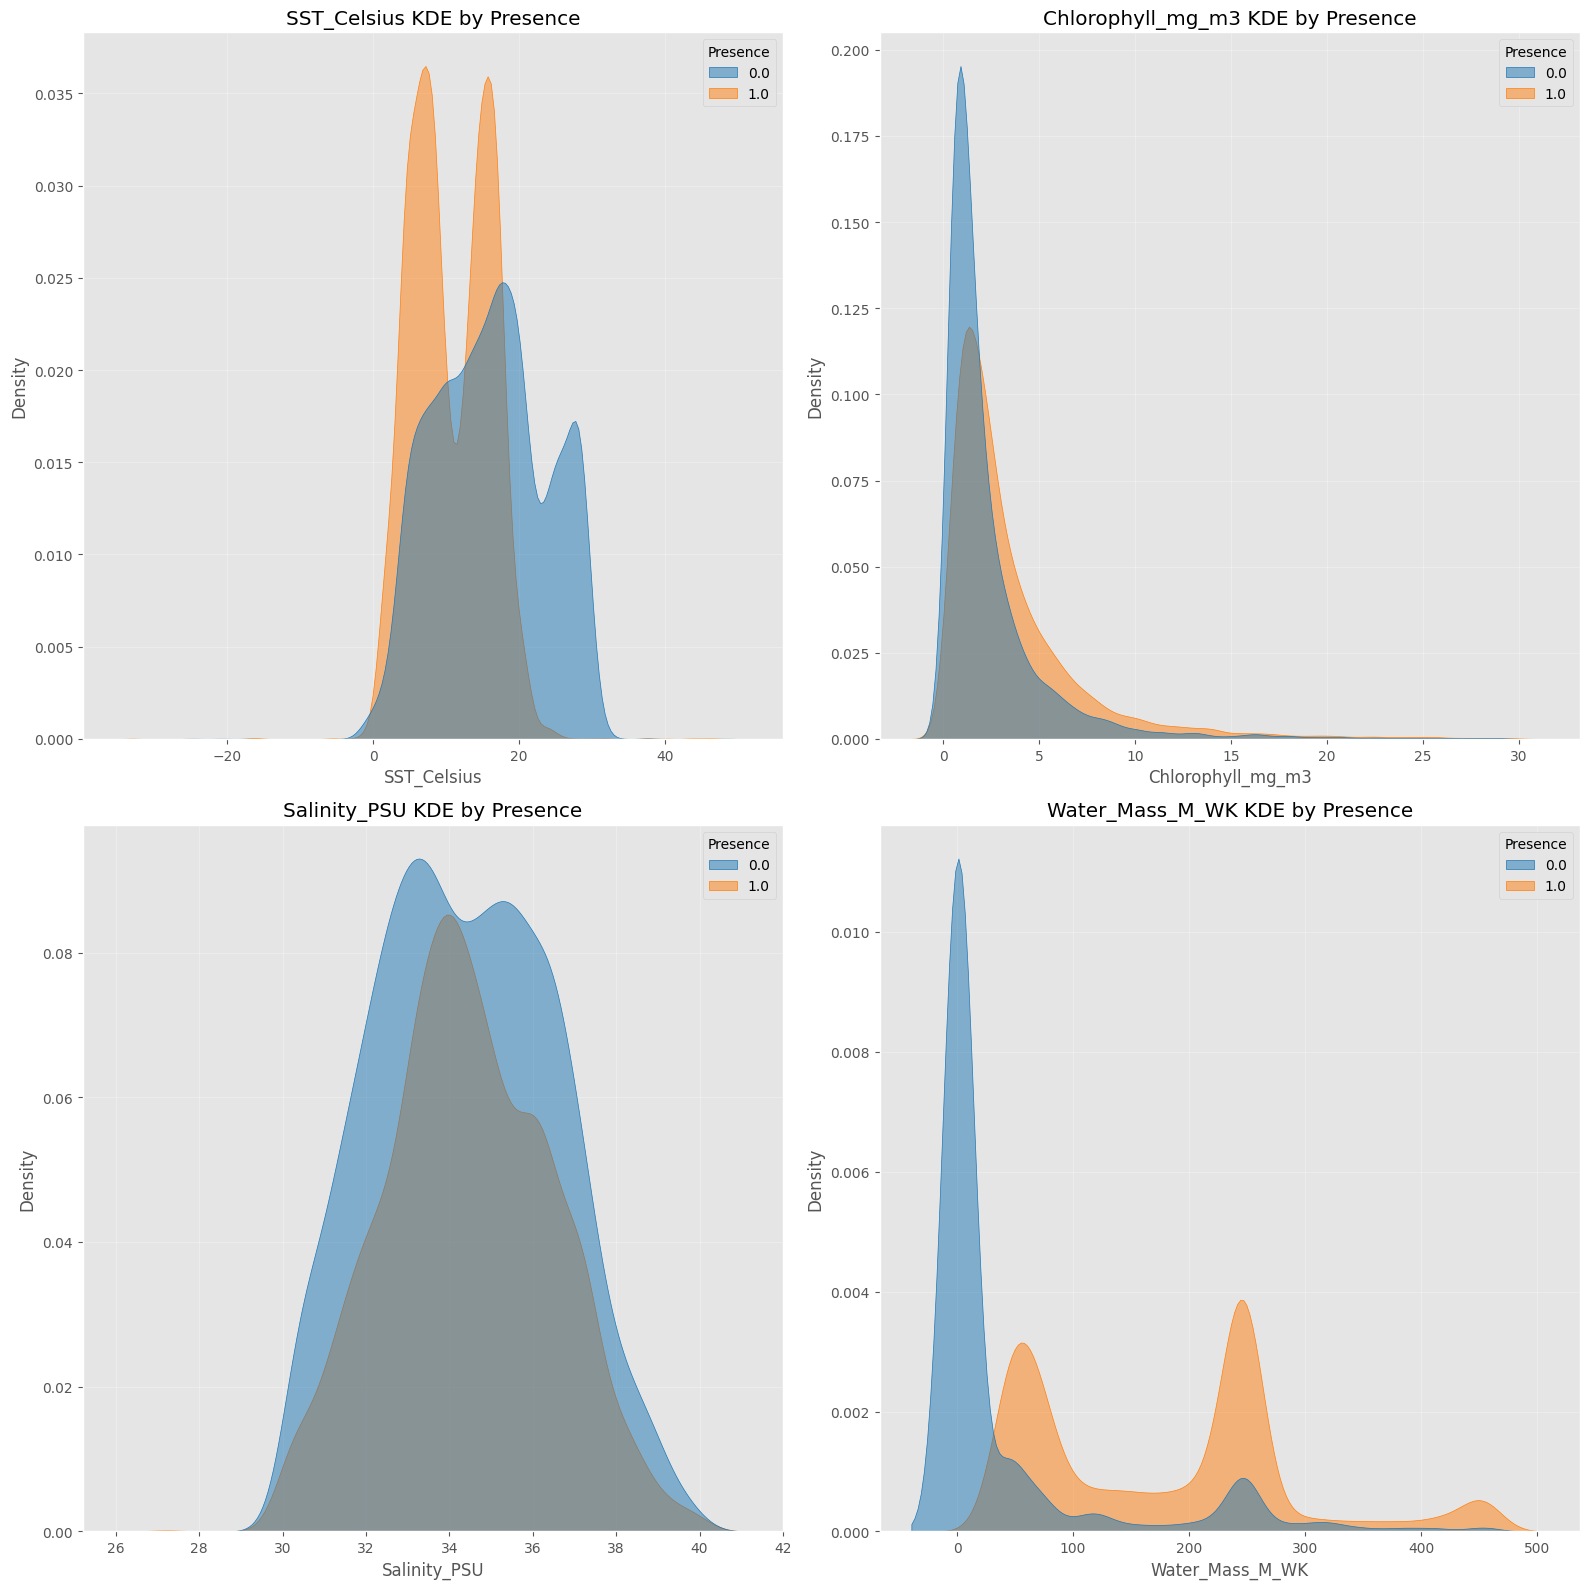

In [678]:
numeric_cols = ['SST_Celsius', 'Chlorophyll_mg_m3', 'Salinity_PSU', 'Water_Mass_M_WK']

df = df[(df['SST_Celsius'] >= -40) & (df['SST_Celsius'] <= 50)]
df = df[(df['Chlorophyll_mg_m3'] >= 0) & (df['Chlorophyll_mg_m3'] <= 30)]

print(f"After outlier removal: {len(df)} rows remaining")

# KDE plots for numeric features
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.kdeplot(data=df, x=col, hue='Presence', ax=ax, fill=True, alpha=0.5, palette=['#1f77b4', '#ff7f0e'])
    ax.set_title(f'{col} KDE by Presence')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

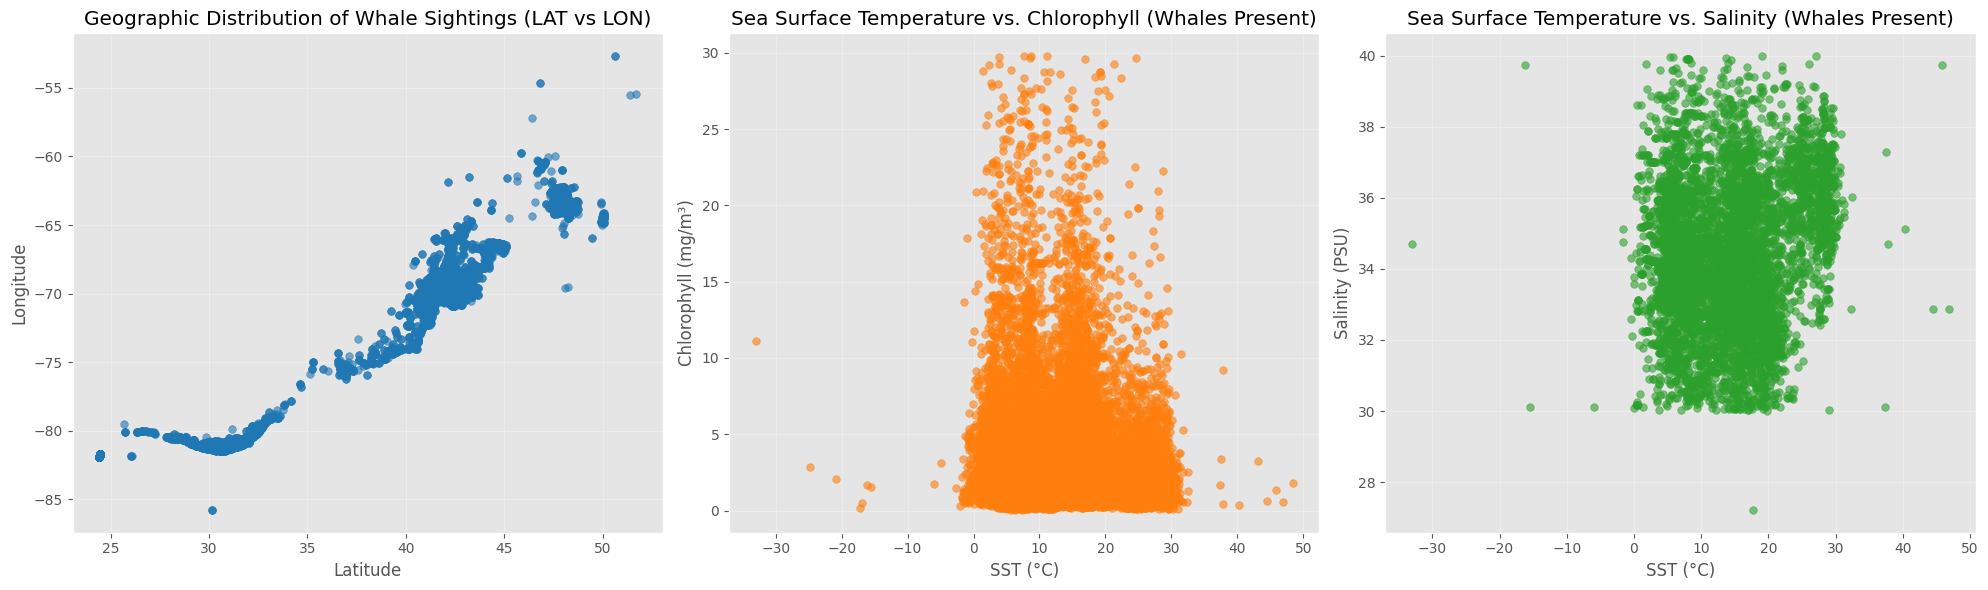

In [679]:
# All three scatter plots in one cell
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Geographic distribution (LAT vs LON)
axes[0].scatter(df['LAT'], df['LON'], alpha=0.6, s=30, color='#1f77b4')
axes[0].set_xlabel('Latitude')
axes[0].set_ylabel('Longitude')
axes[0].set_title('Geographic Distribution of Whale Sightings (LAT vs LON)')
axes[0].grid(alpha=0.3)

# 2. SST vs Chlorophyll relationship
series2 = df[['SST_Celsius', 'Chlorophyll_mg_m3']].dropna()
axes[1].scatter(series2['SST_Celsius'], series2['Chlorophyll_mg_m3'], alpha=0.6, s=30, color='#ff7f0e')
axes[1].set_xlabel('SST (°C)')
axes[1].set_ylabel('Chlorophyll (mg/m³)')
axes[1].set_title('Sea Surface Temperature vs. Chlorophyll (Whales Present)')
axes[1].grid(alpha=0.3)

# 3. SST vs Salinity relationship
series3 = df[['SST_Celsius', 'Salinity_PSU']].dropna()
axes[2].scatter(series3['SST_Celsius'], series3['Salinity_PSU'], alpha=0.6, s=30, color='#2ca02c')
axes[2].set_xlabel('SST (°C)')
axes[2].set_ylabel('Salinity (PSU)')
axes[2].set_title('Sea Surface Temperature vs. Salinity (Whales Present)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [680]:
df_corr = df[['SST_Celsius','Chlorophyll_mg_m3', 
              'Salinity_PSU', 'Water_Mass_M_WK']].dropna().corr()
df_corr

,SST_Celsius,Chlorophyll_mg_m3,Salinity_PSU,Water_Mass_M_WK
SST_Celsius,1.000000,-0.095647,0.143170,-0.327131
Chlorophyll_mg_m3,-0.095647,1.000000,0.052599,-0.001867
Salinity_PSU,0.143170,0.052599,1.000000,0.093242
Water_Mass_M_WK,-0.327131,-0.001867,0.093242,1.000000


<Axes: >

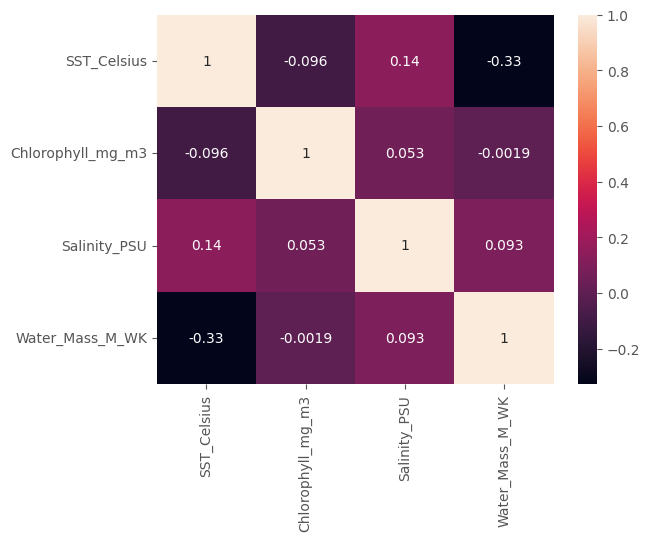

In [681]:
sns.heatmap(df_corr, annot=True)

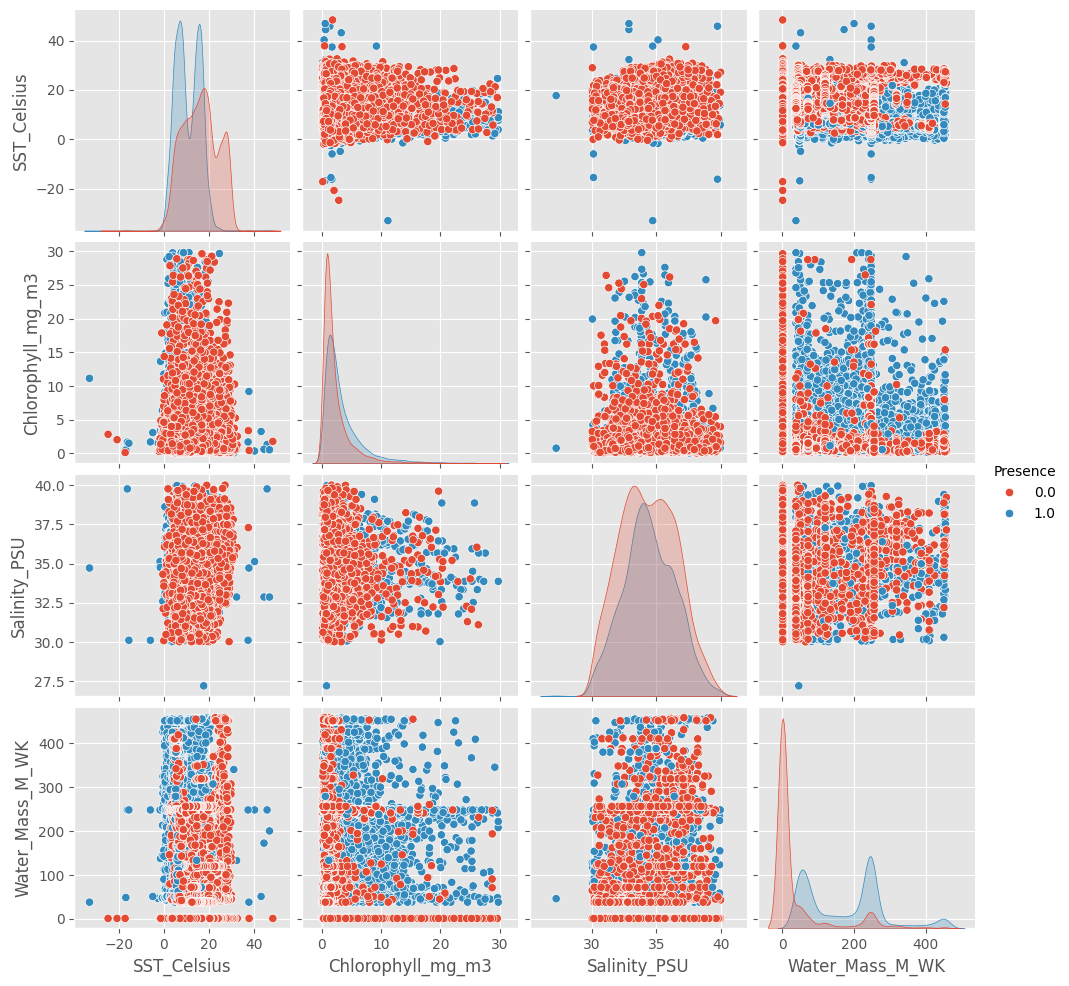

In [682]:
sns.pairplot(df,
             vars=['SST_Celsius', 'Chlorophyll_mg_m3', 'Salinity_PSU', 'Water_Mass_M_WK'],
            hue='Presence')
plt.show()

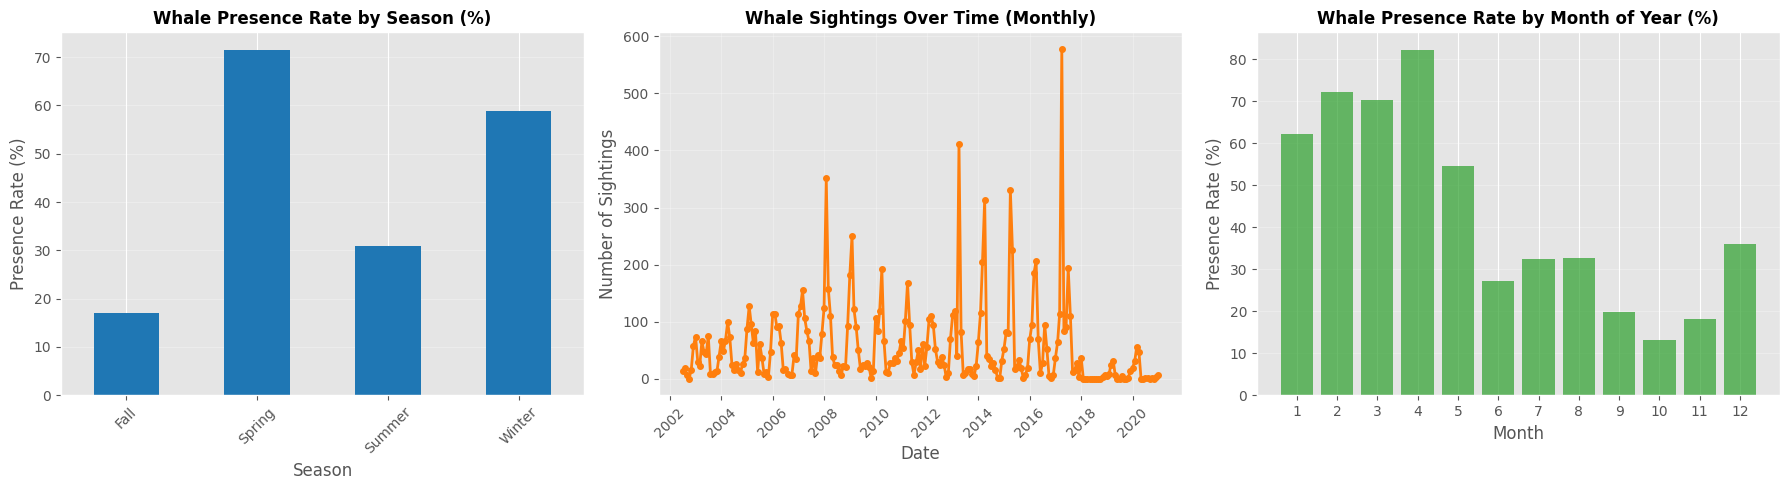


Seasonal Presence Rates:
  Fall: 17.00%
  Spring: 71.55%
  Summer: 30.84%
  Winter: 58.94%


In [683]:
# Create forecasting-focused EDA visualizations
fig = plt.figure(figsize=(18, 5))

# 1. Presence by Season
ax1 = plt.subplot(1, 3, 1)
season_presence = df.groupby('Season')['Presence'].agg(['sum', 'count'])
season_presence['presence_rate'] = season_presence['sum'] / season_presence['count'] * 100
season_presence['presence_rate'].plot(kind='bar', ax=ax1, color='#1f77b4')
ax1.set_title('Whale Presence Rate by Season (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Season')
ax1.set_ylabel('Presence Rate (%)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.grid(alpha=0.3, axis='y')

# 2. Temporal Trend - Sightings over time
ax2 = plt.subplot(1, 3, 2)
df_time = df[df['Presence'] == 1].set_index('SIGHTINGDATE').resample('MS').size()
ax2.plot(df_time.index, df_time.values, linewidth=2, color='#ff7f0e', marker='o', markersize=4)
ax2.set_title('Whale Sightings Over Time (Monthly)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Number of Sightings')
ax2.grid(alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# 3. Presence by Month
ax3 = plt.subplot(1, 3, 3)
df['Month'] = df['SIGHTINGDATE'].dt.month
month_presence = df.groupby('Month')['Presence'].agg(['sum', 'count'])
month_presence['presence_rate'] = month_presence['sum'] / month_presence['count'] * 100
ax3.bar(month_presence.index, month_presence['presence_rate'], color='#2ca02c', alpha=0.7)
ax3.set_title('Whale Presence Rate by Month of Year (%)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Presence Rate (%)')
ax3.set_xticks(range(1, 13))
ax3.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
class_counts = df['Presence'].value_counts()
print("="*70)
print(f"\nSeasonal Presence Rates:")
for season in season_presence.index:
    print(f"  {season}: {season_presence.loc[season, 'presence_rate']:.2f}%")